# Extended Data Fig. 19a,b - Registration robustness validated by NCC within a global tissue mask

Full chain from the registered cell points:
1. Build each sample's 50 um NeuN density image from the SCA-registered cell points (the NCC input).
2. Build a global common tissue mask (atlas AND every sample > 0), erode it by the NCC window radius, and compute a masked normalized cross-correlation (NCC, 9x9 window) between atlas and each sample; only values inside the eroded mask are kept (these are the masked NCC maps).
3. ED19a: mean NCC along the coronal axis within the global tissue mask, per sample with the overall mean.
4. ED19b: within App-NL-G-F-specific neuronal-decrease regions, mean-centered per-animal NCC across WT 2m (8w), WT 9m (Ctr9m) and App 9m; inter-animal variance tested with Levene's test (P = 0.898, N.S.).

> Figures preserved from the original run; Japanese stripped from comments; verbose logs removed.

## Input files

| File | Content |
|---|---|
| per-sample `SCA_registered_cell_coordinates_ver2_2.bin` + classified-cell `.bin` | registered NeuN cell points (step 1 input) |
| `SCA_averaged_50um_Nuclear_density.tif` / `..._NeuN_density.tif` | atlas templates |
| `SCA_iso_50um_Nuclear_density_with_ventricles_Trial_Neuron_<sample>.tif` | per-sample density image (built in step 1; mask + NCC input) |
| `ncc_map_3d_Trial_Neuron_ver_GlobalMask_AND_Eroded_Code2_3conditions_<sample>.tif` | masked NCC maps (built in step 2) |
| `APP_/WT_raw_value_regions_NeuN_decrease.csv`, `annotation_50_LUT_modified.tif` | App-specific regions / annotation |

Samples: WT 2m (8w, n=6), WT 9m (Ctr9m, n=4), App 9m (n=4).

## 1. Build each sample's 50 um NeuN density image from SCA-registered cell points

In [ ]:
Samples = ["#3_TMTmodel_Saline_8w_1_2022_1016_1318", "#3_TMTmodel_Saline_8w_2_2022_1018_2103","#3_TMTmodel_Saline_8w_3_2022_1021_1910", "#3_TMTmodel_Saline_8w_4_2022_1202_1349", "#3_TMTmodel_Saline_8w_5_2022_1217_1723", "#3_TMTmodel_Saline_8w_6_2022_1216_001"]

for Sample in Samples:
    print(Sample)
    start_time = datetime.datetime.now()
    print("Start time:", start_time)

    #
    param_path = "/home/mitani/CUBIC-informatics/param/Neuronomics/" + Sample + "/param_multichannel-rank.json"
    
    with open(param_path) as f:
        param = json.load(f)

    fw_dir_nu = param["dst_basedir"]
    #######################################
    if ("Neurology_project_data_archive" not in fw_dir_nu and
        not re.search(r'/ds1_Imaging[23]/', fw_dir_nu)):

        fw_dir_nu = re.sub(
            r'^(/data\d+/)',                    # /dataX/  
            r'\1Neurology_project_data_archive/',
            fw_dir_nu
        )
    ##########################################
    print(fw_dir_nu )
    
    #
    dt_annotation2 = np.dtype([
      ('stitched_x', 'f4'), ('stitched_y', 'f4'), ('stitched_z', 'f4'),
      ('mapped_x', 'f4'), ('mapped_y', 'f4'), ('mapped_z', 'f4'),
      ('SCA_x', 'f4'), ('SCA_y', 'f4'), ('SCA_z', 'f4'),
      ('atlas_id', 'u2')
    ])

    dt_annotated2 = np.dtype([
        ('X(um)', 'f4'), ('Y(um)', 'f4'), ('Z(um)', 'f4'),
        ('SCA_x', 'f4'), ('SCA_y', 'f4'), ('SCA_z', 'f4'),
    ])

    start_time = datetime.datetime.now()
    print("Start time:", start_time)

    downscale_unit = 1.0

    df_src = np.fromfile(fw_dir_nu+"SCA_registered_cell_coordinates_ver2_2.bin", dtype=dt_annotation2)
    
    Classified_cells = np.fromfile(fw_dir_nu+"For_PDF_clustering_base_data_classified_NeuN_" + str(NeuN_cluster_threshold_list[0]) +
             "_noise_"+str(NeuN_cluster_noise_threshold_list[0]) +
             "_Iba1_" +str(Iba1_cluster_threshold_list[0])  +"_2.bin", dtype = dt_simple2 )

    df_src = df_src[(df_src["atlas_id"] > 0)&(Classified_cells["NeuN_positive"] > 0)]
    
    img_filename_Nuclear_Isocortex_to_ori = '/data4/ds1_Imaging3/CUBIC-Atlas-1.2/'+ "SCA_iso_50um_Nuclear_density_with_ventricles_Trial_Neuron_"+Sample+".tif"

    #
    scale = 1 / 50 
    depth_ori = 160 #800 
    height_ori = 264 # 1320
    width_ori = 228 #1140

    #
    final_image = np.zeros((depth_ori, height_ori, width_ori), dtype=np.float32)

    #
    positions = np.vstack([
        df_src["SCA_z"],
        df_src["SCA_y"],
        df_src["SCA_x"]
    ]).T * scale

    range_z = (0, depth_ori)
    range_y = (0, height_ori)
    range_x = (0, width_ori)

    #
    final_image, _ = np.histogramdd(
        positions,
        bins=(depth_ori , height_ori , width_ori),
        range=[range_z, range_y, range_x]
    )

    tifffile.imsave(img_filename_Nuclear_Isocortex_to_ori, final_image.astype(np.uint16))

    #data_annotated.tofile(src_csv_path + "Transformed_to_R_atlas_space_Cell_coordinates.bin")

    end_time = datetime.datetime.now()
    print("Point transfer End time:", end_time)
    print("Duration:", end_time - start_time)   


    #
    image_I = tifffile.imread('/data4/ds1_Imaging3/CUBIC-Atlas-1.2/'+ "SCA_iso_50um_Nuclear_density_with_ventricles_Trial_Neuron_"+Sample+".tif").astype(np.float32)
    image_J = tifffile.imread('/data4/ds1_Imaging3/Axial/Neurorology/8w_B6JWT_atlas_1_2022_0924_1847/SCA_averaged_50um_NeuN_density.tif').astype(np.float32)

    #
    from scipy.ndimage import uniform_filter 

    #
    radius = 4  #   ( )
    window_size = 2 * radius + 1
    #
    N_total = window_size * window_size 

    #
    ncc_map_3d = np.zeros_like(image_I, dtype=np.float32)

    #
    for y_plane in range(image_I.shape[1]):
        #
        I_slice = image_I[:, y_plane, :]
        J_slice = image_J[:, y_plane, :]

        #

        #
        mask_I = (I_slice > 0).astype(np.float32)
        mask_J = (J_slice > 0).astype(np.float32)
        common_mask = mask_I * mask_J #  0 

        #
        if np.any(common_mask):

            #
            #
            N_valid = uniform_filter(common_mask, size=window_size) * N_total
            #
            N_valid_safe = np.where(N_valid == 0, 1, N_valid)

            #
            #
            mean_I = (uniform_filter(I_slice * common_mask, size=window_size) * N_total) / N_valid_safe
            mean_J = (uniform_filter(J_slice * common_mask, size=window_size) * N_total) / N_valid_safe

            #
            #
            normed_I = (I_slice - mean_I) * common_mask
            normed_J = (J_slice - mean_J) * common_mask

            #
            #
            numerator = (uniform_filter(normed_I * normed_J, size=window_size) * N_total) / N_valid_safe
            norm_I = (uniform_filter(normed_I**2, size=window_size) * N_total) / N_valid_safe
            norm_J = (uniform_filter(normed_J**2, size=window_size) * N_total) / N_valid_safe

            #
            denominator = np.sqrt(norm_I * norm_J)

            #
            #
            ncc_slice = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=(denominator != 0))
            ncc_map_3d[:, y_plane, :] = ncc_slice * (N_valid > 0) #  0 

        else:
            #
            ncc_map_3d[:, y_plane, :] = 0.0

        #

    #
    tifffile.imwrite('/data4/ds1_Imaging3/CUBIC-Atlas-1.2/ncc_map_3d_Trial_Neuron_ver2_'+ Sample +'.tif', ncc_map_3d)
    print("3D NCC map calculated and saved with correct dimensions.")
    print(np.nanmean(ncc_map_3d[image_J  > 0]))
        

## 2. Global common tissue mask + masked NCC map computation

In [ ]:
import numpy as np
import tifffile
import datetime
import json
import re
from scipy.ndimage import uniform_filter
import scipy.ndimage as ndi  #  (Erosion) 

#
Samples=[  
    "#3_TMTmodel_Saline_8w_1_2022_1016_1318",
    "#3_TMTmodel_Saline_8w_2_2022_1018_2103",
    "#3_TMTmodel_Saline_8w_3_2022_1021_1910",
    "#3_TMTmodel_Saline_8w_4_2022_1202_1349",
    "#3_TMTmodel_Saline_8w_5_2022_1217_1723",
    "#3_TMTmodel_Saline_8w_6_2022_1216_001",
    
    "#5_APPmodel_Ctr9m_1_2023_0130_1607", 
    "#5_APPmodel_Ctr9m_2_2023_0216_2052" ,
    "#5_APPmodel_Ctr9m_3_2023_0322_2014",
    "#5_APPmodel_Ctr9m_4_2023_0518_1449",
    "#5_APPmodel_APP9m_1_2023_0117_1352",
    "#5_APPmodel_APP9m_2_2023_0327_1425", 
    "#5_APPmodel_APP9m_3_2023_0329_1611", 
    "#5_APPmodel_APP9m_4_2023_0403_1443" 
]
#################################################################
#
#################################################################
print("---  2 NCC  ---")

#
#
print(" ...")
image_J_atlas_path = '/data4/ds1_Imaging3/Axial/Neurorology/8w_B6JWT_atlas_1_2022_0924_1847/SCA_averaged_50um_Nuclear_density.tif'
image_J_atlas = tifffile.imread(image_J_atlas_path).astype(np.float32)
atlas_mask = (image_J_atlas > 0)
intersection_sample_mask = np.ones_like(atlas_mask, dtype=bool) 
for Sample in Samples:
    #
    #
    #
    sample_img_path = f'/data4/ds1_Imaging3/CUBIC-Atlas-1.2/SCA_iso_50um_Nuclear_density_with_ventricles_Trial_{Sample}.tif'
    image_I_sample = tifffile.imread(sample_img_path).astype(np.float32)
    intersection_sample_mask = intersection_sample_mask & (image_I_sample > 0)
global_common_mask_3d = atlas_mask & intersection_sample_mask
print(" ")


#

#
radius = 4
window_size = 2 * radius + 1

#
structure_2d = ndi.generate_binary_structure(rank=2, connectivity=1)
erosion_structure = ndi.iterate_structure(structure_2d, iterations=radius)

for Sample in Samples:
    print(f"NCC : {Sample}")
    
    #
    image_I = tifffile.imread(f'/data4/ds1_Imaging3/CUBIC-Atlas-1.2/SCA_iso_50um_Nuclear_density_with_ventricles_Trial_Neuron_{Sample}.tif').astype(np.float32)
    image_J = image_J_atlas 
    
    ncc_map_3d = np.zeros_like(image_I, dtype=np.float32)

    #
    for y_plane in range(image_I.shape[1]):
        I_slice = image_I[:, y_plane, :]
        J_slice = image_J[:, y_plane, :]
        
        #
        global_mask_slice = global_common_mask_3d[:, y_plane, :]
        
        #
        eroded_mask_slice = ndi.binary_erosion(global_mask_slice, structure=erosion_structure) # Boolean

        #
        if np.any(eroded_mask_slice):
            
            #
            I_slice_masked = I_slice * eroded_mask_slice
            J_slice_masked = J_slice * eroded_mask_slice

            #
            #
            mean_I = uniform_filter(I_slice_masked, size=window_size)
            mean_J = uniform_filter(J_slice_masked, size=window_size)

            #
            #
            normed_I = I_slice_masked - mean_I
            normed_J = J_slice_masked - mean_J

            #
            norm_I = uniform_filter(normed_I**2, size=window_size)
            norm_J = uniform_filter(normed_J**2, size=window_size)

            #
            numerator = uniform_filter(normed_I * normed_J, size=window_size)
            denominator = np.sqrt(norm_I * norm_J)

            #
            ncc_slice = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=(denominator != 0))
            
            #
            #
            ncc_map_3d[:, y_plane, :] = ncc_slice * eroded_mask_slice
        
        else:
            #
            ncc_map_3d[:, y_plane, :] = 0.0

    #
    output_filename = f'/data4/ds1_Imaging3/CUBIC-Atlas-1.2/ncc_map_3d_Trial_Neuron_ver_GlobalMask_AND_Eroded_Code2_3conditions_{Sample}.tif'
    tifffile.imwrite(output_filename, ncc_map_3d)
    print(f"NCC : {output_filename}")
    print(np.nanmean(ncc_map_3d[image_J > 0]))

print("---  2 NCC  ---")

## 3. Mean NCC along the coronal axis within the global tissue mask (Extended Data Fig. 19a)

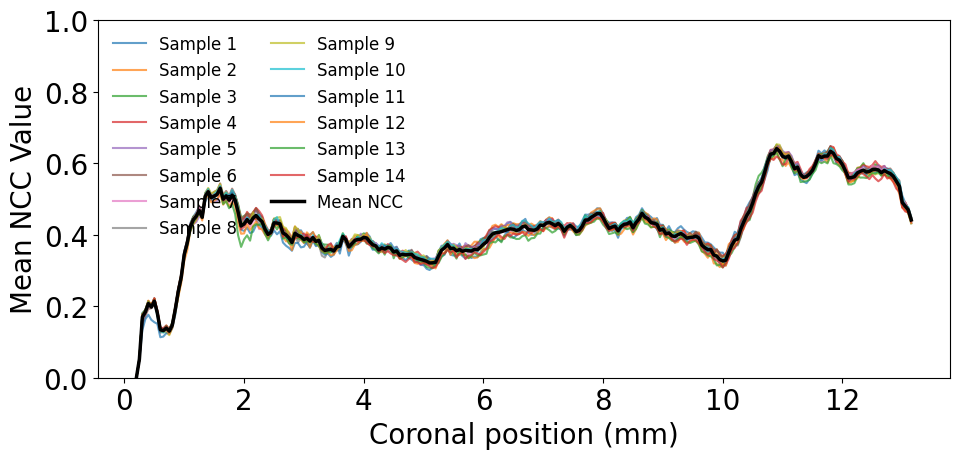

In [1]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt
import datetime
import matplotlib
import scipy.ndimage as ndi  #  (Erosion) 

matplotlib.rcParams['pdf.use14corefonts'] = True
plt.rcParams['font.size'] = 20

#
Samples=[  
    "#3_TMTmodel_Saline_8w_1_2022_1016_1318",
    "#3_TMTmodel_Saline_8w_2_2022_1018_2103",
    "#3_TMTmodel_Saline_8w_3_2022_1021_1910",
    "#3_TMTmodel_Saline_8w_4_2022_1202_1349",
    "#3_TMTmodel_Saline_8w_5_2022_1217_1723",
    "#3_TMTmodel_Saline_8w_6_2022_1216_001",
    
    "#5_APPmodel_Ctr9m_1_2023_0130_1607", 
    "#5_APPmodel_Ctr9m_2_2023_0216_2052" ,
    "#5_APPmodel_Ctr9m_3_2023_0322_2014",
    "#5_APPmodel_Ctr9m_4_2023_0518_1449",
    "#5_APPmodel_APP9m_1_2023_0117_1352",
    "#5_APPmodel_APP9m_2_2023_0327_1425", 
    "#5_APPmodel_APP9m_3_2023_0329_1611", 
    "#5_APPmodel_APP9m_4_2023_0403_1443" 
]

sample_labels = [f"Sample {i+1}" for i in range(len(Samples))]

#
image_J_atlas = tifffile.imread(
    '/data4/ds1_Imaging3/Axial/Neurorology/8w_B6JWT_atlas_1_2022_0924_1847/SCA_averaged_50um_nuclear_density.tif'
).astype(np.float32)

y_coords = np.arange(image_J_atlas.shape[1])
y_coords_mm = y_coords * 0.05

all_ncc_means = []
plt.figure(figsize=(10, 5))

#

#
print(" (AND) ...")
atlas_mask = (image_J_atlas > 0)
#
intersection_sample_mask = np.ones_like(atlas_mask, dtype=bool) 
for Sample in Samples:
    sample_img_path = f'/data4/ds1_Imaging3/CUBIC-Atlas-1.2/SCA_iso_50um_Nuclear_density_with_ventricles_Trial_Neuron_{Sample}.tif'
    image_I_sample = tifffile.imread(sample_img_path).astype(np.float32)
    intersection_sample_mask = intersection_sample_mask & (image_I_sample > 0)

#
global_common_mask_3d = atlas_mask & intersection_sample_mask
print(" ")


#
radius = 4 # NCC 
structure_2d = ndi.generate_binary_structure(rank=2, connectivity=1)
erosion_structure = ndi.iterate_structure(structure_2d, iterations=radius)

#
for Sample in Samples:
    
    #
    image_I_ncc = tifffile.imread(f'/data4/ds1_Imaging3/CUBIC-Atlas-1.2/ncc_map_3d_Trial_Neuron_ver_GlobalMask_AND_Eroded_Code2_3conditions_{Sample}.tif')
    
    ncc_means = []
    
    #
    for y in range(image_I_ncc.shape[1]):  # y 
        
        #
        global_mask_slice = global_common_mask_3d[:, y, :]
        
        #
        #eroded_mask = ndi.binary_erosion(global_mask_slice, structure=erosion_structure)
        eroded_mask = global_mask_slice
        #
        #ncc_valid_mask = image_I_ncc[:, y, :] > 0.001
        
        #
        final_mask = eroded_mask #& ncc_valid_mask

        if np.any(final_mask):  #  
            #
            ncc_mean = np.mean(image_I_ncc[:, y, :][final_mask])
        else:
            #
            ncc_mean = np.nan  
            
        ncc_means.append(ncc_mean)
    
    #

    all_ncc_means.append(ncc_means)
    plt.plot(y_coords_mm, ncc_means, label=sample_labels[Samples.index(Sample)], alpha=0.7)
    
#
all_ncc_means = np.array(all_ncc_means)
mean_ncc = np.nanmean(all_ncc_means, axis=0) # NaN 

plt.plot(y_coords_mm, mean_ncc, color='black', linewidth=2.5, label='Mean NCC')
plt.xlabel('Coronal position (mm)')
plt.ylabel('Mean NCC Value')
legend = plt.legend(loc='best', fontsize=12, frameon=False, ncol=2)
legend.get_frame().set_alpha(0)
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.2))
plt.grid(False)
plt.gca().set_facecolor((1, 1, 1, 0))
plt.tight_layout()
#plt.savefig(f"/data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/Repeatability_Neuron_NCC_Using_Eroded_Global_mask.pdf",
#            transparent=True, dpi=300, bbox_inches='tight', pad_inches=0.1)

plt.show()

## 4. Inter-animal NCC variance in App-specific regions; Levene's test (Extended Data Fig. 19b)

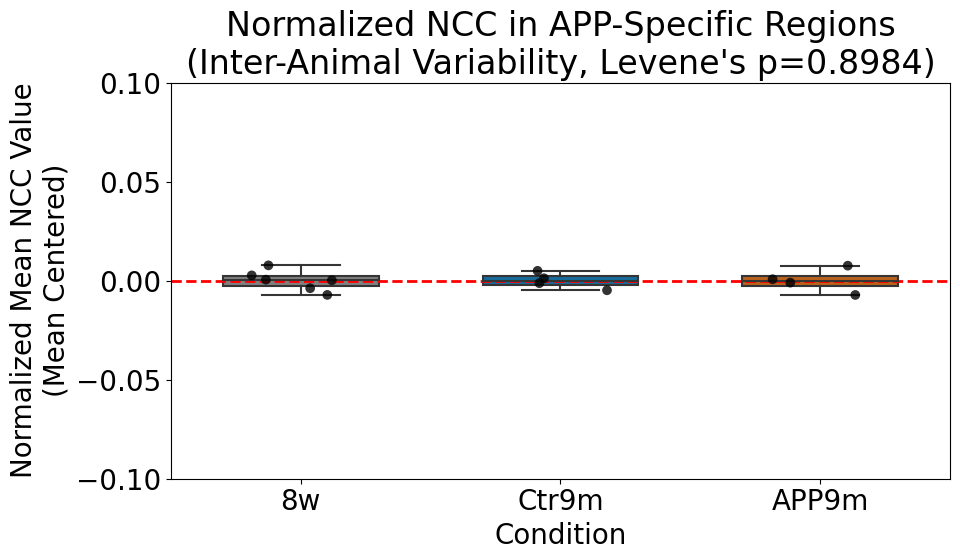

In [2]:
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.multicomp import MultiComparison
import re
import scipy.ndimage as ndi
from scipy.stats import levene
matplotlib.rcParams['pdf.use14corefonts'] = True
plt.rcParams['font.size'] = 20
#
#
#
Samples = [
    "#3_TMTmodel_Saline_8w_1_2022_1016_1318",
    "#3_TMTmodel_Saline_8w_2_2022_1018_2103",
    "#3_TMTmodel_Saline_8w_3_2022_1021_1910",
    "#3_TMTmodel_Saline_8w_4_2022_1202_1349",
    "#3_TMTmodel_Saline_8w_5_2022_1217_1723",
    "#3_TMTmodel_Saline_8w_6_2022_1216_001",
    
    "#5_APPmodel_Ctr9m_1_2023_0130_1607", 
    "#5_APPmodel_Ctr9m_2_2023_0216_2052",
    "#5_APPmodel_Ctr9m_3_2023_0322_2014",
    "#5_APPmodel_Ctr9m_4_2023_0518_1449",
    "#5_APPmodel_APP9m_1_2023_0117_1352",
    "#5_APPmodel_APP9m_2_2023_0327_1425", 
    "#5_APPmodel_APP9m_3_2023_0329_1611", 
    "#5_APPmodel_APP9m_4_2023_0403_1443" 
]
def get_condition(sample_name):
    if "TMTmodel_Saline_8w" in sample_name: return "8w"
    elif "APPmodel_Ctr9m" in sample_name: return "Ctr9m"
    elif "APPmodel_APP9m" in sample_name: return "APP9m"
    return None
print("--- 1. APP ROI atlasID  ---")
X = pd.read_csv('/data4/Neurology_project_data_archive/Region/APP_raw_value_regions_NeuN_decrease.csv', index_col='atlasID')
X2 = pd.read_csv('/data4/Neurology_project_data_archive/Region/WT_raw_value_regions_NeuN_decrease.csv', index_col='atlasID')
app_specific_ids = X[~X.index.isin(X2.index)].index.tolist()
annotation_map_path = '/data4/ds1_Imaging3/CUBIC-Atlas-R-test/annotation_50_LUT_modified.tif'
annotation_map = tifffile.imread(annotation_map_path)
print("\n--- 2.  (AND) ... ---")
image_J_atlas = tifffile.imread(
    '/data4/ds1_Imaging3/Axial/Neurorology/8w_B6JWT_atlas_1_2022_0924_1847/SCA_averaged_50um_nuclear_density.tif'
).astype(np.float32)
atlas_mask = (image_J_atlas > 0)
intersection_sample_mask = np.ones_like(atlas_mask, dtype=bool) 
for Sample in Samples:
    try:
        sample_img_path = f'/data4/ds1_Imaging3/CUBIC-Atlas-1.2/SCA_iso_50um_Nuclear_density_with_ventricles_Trial_{Sample}.tif'
        image_I_sample = tifffile.imread(sample_img_path).astype(np.float32)
        intersection_sample_mask = intersection_sample_mask & (image_I_sample > 0)
    except FileNotFoundError:
        print(f" : {sample_img_path}  ")
global_common_mask_3d = atlas_mask & intersection_sample_mask
radius = 4
structure_2d = ndi.generate_binary_structure(rank=2, connectivity=1)
erosion_structure = ndi.iterate_structure(structure_2d, iterations=radius)
eroded_global_mask_3d = np.zeros_like(global_common_mask_3d, dtype=bool)
for y_plane in range(global_common_mask_3d.shape[1]):
    eroded_global_mask_3d[:, y_plane, :] = ndi.binary_erosion(
        global_common_mask_3d[:, y_plane, :], 
        structure=erosion_structure
    )
print(" 3D ")

#
#
print("\n--- 3.  NCC  ---")
region_results = []
calculation_mask = eroded_global_mask_3d
if not np.any(calculation_mask):
    print(" :  ")
else:
    ncc_maps = {}
    for sample_name in Samples:
        ncc_map_path = f'/data4/ds1_Imaging3/CUBIC-Atlas-1.2/ncc_map_3d_Trial_Neuron_ver_GlobalMask_AND_Eroded_Code2_3conditions_{sample_name}.tif'
        try:
            ncc_maps[sample_name] = tifffile.imread(ncc_map_path)
        except FileNotFoundError:
            print(f" : {ncc_map_path}  ")
    if not ncc_maps:
        print(" :  NCC ")
    else:
        for region_id in app_specific_ids:
            roi_mask_for_region = (annotation_map == region_id)
            final_extraction_mask = roi_mask_for_region & calculation_mask
            if not np.any(final_extraction_mask):
                continue
            for sample_name in Samples:
                if sample_name not in ncc_maps:
                    continue
                ncc_map = ncc_maps[sample_name]
                ncc_values_in_roi = ncc_map[final_extraction_mask]
                ncc_values_in_roi = ncc_values_in_roi[ncc_values_in_roi > 0] 
                if len(ncc_values_in_roi) > 0:
                    mean_ncc_for_sample_region = np.mean(ncc_values_in_roi)
                    region_results.append({
                        "atlasID": region_id,
                        "Sample": sample_name,
                        "Condition": get_condition(sample_name),
                        "Mean_NCC": mean_ncc_for_sample_region
                    })

#
print("\n--- 4.  NCC  ---")

if not region_results:
    print(" :  ")
else:
    df_regional_ncc = pd.DataFrame(region_results)
    df_sample_means = df_regional_ncc.groupby(['Sample', 'Condition'])['Mean_NCC'].mean().reset_index()
    print(" NCC APP ")
    print(df_sample_means)

    #
    print("\n--- 5.   (Levene's Test   ANOVA) ---")
    
    #
    group_8w = df_sample_means[df_sample_means['Condition'] == '8w']['Mean_NCC'].dropna()
    group_ctr9m = df_sample_means[df_sample_means['Condition'] == 'Ctr9m']['Mean_NCC'].dropna()
    group_app9m = df_sample_means[df_sample_means['Condition'] == 'APP9m']['Mean_NCC'].dropna()

    #
    print("\n--- 5a.   (Levene's Test) ---")
    stat_levene, p_levene = levene(group_8w, group_ctr9m, group_app9m)
    print(f"Levene's Test ( ):")
    print(f"  Statistic = {stat_levene:.4f}, P-value = {p_levene:.4g}")
    if p_levene > 0.05:
        print("  -> P > 0.05:  ")
    else:
        print("  -> P < 0.05:  ")

    #
    print("\n--- 5b.   (ANOVA / Tukey) ---")
    f_val, p_val = stats.f_oneway(group_8w, group_ctr9m, group_app9m)
    print(f"One-way ANOVA ( ):")
    print(f"  F-statistic = {f_val:.4f}, P-value = {p_val:.4g}")
    #

    #
    print("\n--- 6.   ( 0 ) ---")
    
    df_normalized = df_sample_means.copy()
    
    #
    mean_8w = group_8w.mean()
    mean_ctr9m = group_ctr9m.mean()
    mean_app9m = group_app9m.mean()

    #
    def normalize_by_group(row):
        if row['Condition'] == '8w':
            return row['Mean_NCC'] - mean_8w
        elif row['Condition'] == 'Ctr9m':
            return row['Mean_NCC'] - mean_ctr9m
        elif row['Condition'] == 'APP9m':
            return row['Mean_NCC'] - mean_app9m
    
    df_normalized['Normalized_NCC'] = df_normalized.apply(normalize_by_group, axis=1)
    print(" 0 ")
    
    #
    print("\n--- 7.  NCC  ---")
    
    plt.rcParams['font.size'] = 20
    plt.rcParams['pdf.use14corefonts'] = True
    fig, ax = plt.subplots(figsize=(10, 6))

    #
    sns.boxplot(
        data=df_normalized, #    
        x='Condition',
        y='Normalized_NCC', #    Y 
        order=['8w', 'Ctr9m', 'APP9m'],
        palette=['#808080', '#0072B2', '#D55E00'],
        width=0.6,
        ax=ax
    )
    
    #
    sns.stripplot(
        data=df_normalized, #    
        x='Condition',
        y='Normalized_NCC', #    Y 
        order=['8w', 'Ctr9m', 'APP9m'],
        color='black', 
        jitter=0.2, 
        size=7,
        alpha=0.8,
        ax=ax
    )
    
    #
    ax.axhline(0, color='red', linestyle='--', linewidth=2)
    
    ax.set_title(f"Normalized NCC in APP-Specific Regions\n(Inter-Animal Variability, Levene's p={p_levene:.4f})")
    ax.set_xlabel('Condition')
    ax.set_ylabel('Normalized Mean NCC Value\n(Mean Centered)')
    
    ax.set_ylim(-0.1, 0.1)
    ax.set_yticks([-0.1, -0.05, 0, 0.05, 0.1])
    plt.tight_layout()
    plt.savefig(f"/data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/NCC_variability_8w_Ctr9m_App9m.pdf",
            transparent=True, dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()